In [7]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = [
    "AAPL","MSFT","GOOGL","NVDA","ORCL","CSCO","IBM",
    "AMZN","HD","MCD","NKE","SBUX","WMT","PG","KO","PEP",
    "JPM","BAC","GS","AXP","JNJ","PFE","MRK","UNH",
    "CAT","BA","GE","XOM","CVX","VZ",
]
benchmark = "SPY"

data = yf.download(tickers + [benchmark], start="2010-01-01", auto_adjust=False)["Adj Close"]
data = data.ffill(limit=5).dropna(axis=1, thresh=int(len(data)*0.9))

prices = data.drop(columns=[benchmark])
print(data.shape, "|", data.index.min().date(), "->", data.index.max().date())

[*********************100%***********************]  31 of 31 completed

(4208, 31) | 2010-01-04 -> 2026-09-25


In [8]:
lookback, skip = 252, 21
momentum = prices.shift(skip) / prices.shift(lookback) - 1
start = momentum.dropna().index.min()
print("Momentum calculé. Première date valide :", start.date())

Momentum calculé. Première date valide : 2011-01-03


In [9]:
n_stocks = momentum.shape[1]
n_side = int(n_stocks * 0.2)

def build_weights(row):
    if row.isna().all():
        return pd.Series(0.0, index=row.index)
    ranks = row.rank(ascending=False)
    w = pd.Series(0.0, index=row.index)
    w[ranks <= n_side] = 1.0 / n_side
    w[ranks > n_stocks - n_side] = -1.0 / n_side
    return w

returns = prices.pct_change()
cost_per_turn = 0.0010
first_days = momentum.groupby([momentum.index.year, momentum.index.month]).head(1).index

def to_monthly(w):
    w_masked = w.copy()
    w_masked.loc[~w_masked.index.isin(first_days), :] = np.nan
    return w_masked.ffill()

def backtest(w):
    r = (w.shift(1) * returns).sum(axis=1).loc[start:]
    turn = w.diff().abs().sum(axis=1)
    r_net = r - (turn * cost_per_turn).loc[r.index]
    ann = ((1 + r_net).cumprod().iloc[-1] ** (252/len(r_net)) - 1) * 100
    sharpe = r_net.mean() / r_net.std() * (252**0.5)
    return r_net, sharpe, ann

In [10]:
w_mom_d = momentum.apply(build_weights, axis=1)
w_mom_m = to_monthly(w_mom_d)
w_rev_m = to_monthly((-(prices/prices.shift(5) - 1)).apply(build_weights, axis=1))
w_combo_m = (w_mom_m + w_rev_m) / 2

for name, w in [("Momentum (daily)", w_mom_d),
                ("Momentum (monthly)", w_mom_m),
                ("Reversion 5d (monthly)", w_rev_m),
                ("Combo (monthly)", w_combo_m)]:
    _, s, a = backtest(w)
    print(f"{name:24s} | Sharpe net {s:6.3f} | Rdt annualisé net {a:6.2f}%")

r_mom, _, _ = backtest(w_mom_m)
r_rev, _, _ = backtest(w_rev_m)
print("\nCorrélation momentum/reversion :", round(r_mom.corr(r_rev), 3))

Momentum (daily)         | Sharpe net  0.013 | Rdt annualisé net  -1.97%
Momentum (monthly)       | Sharpe net  0.170 | Rdt annualisé net   1.36%
Reversion 5d (monthly)   | Sharpe net -0.154 | Rdt annualisé net  -4.53%
Combo (monthly)          | Sharpe net  0.043 | Rdt annualisé net  -0.39%

Corrélation momentum/reversion : -0.008


In [11]:
mkt = data[benchmark].pct_change().loc[start:]
r_strat, _, _ = backtest(w_mom_m)

df = pd.concat([r_strat, mkt], axis=1).dropna()
df.columns = ["strat", "mkt"]
X = np.column_stack([np.ones(len(df)), df["mkt"].values])
coef, *_ = np.linalg.lstsq(X, df["strat"].values, rcond=None)
alpha_daily, beta = coef
alpha_annual = (1 + alpha_daily)**252 - 1

print(f"Beta au marché  : {beta:.3f}   (proche de 0 = décorrélé)")
print(f"Alpha annualisé : {alpha_annual*100:.2f}%   (positif = edge réel)")

Beta au marché  : 0.067   (proche de 0 = décorrélé)
Alpha annualisé : 2.65%   (positif = edge réel)


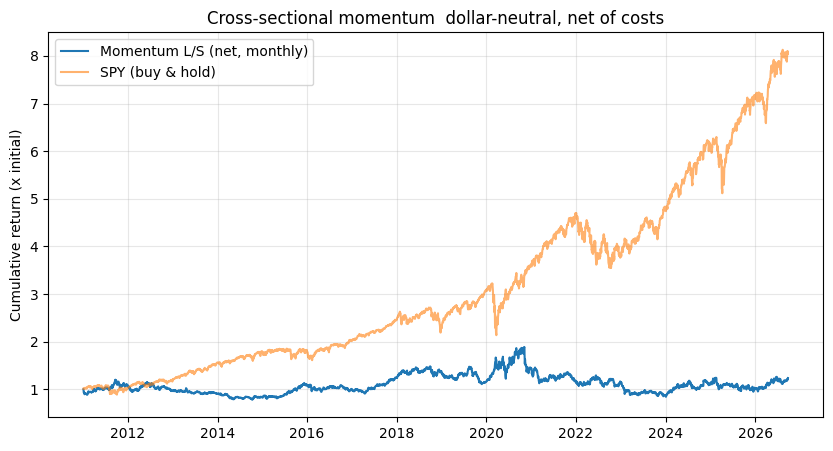

In [12]:
import matplotlib.pyplot as plt

r_strat, _, _ = backtest(w_mom_m)
equity = (1 + r_strat).cumprod()
mkt_equity = (1 + mkt.loc[r_strat.index]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(equity, label="Momentum L/S (net, monthly)")
plt.plot(mkt_equity, label="SPY (buy & hold)", alpha=0.6)
plt.title("Cross-sectional momentum  dollar-neutral, net of costs")
plt.ylabel("Cumulative return (x initial)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig("equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()